# **Libraries**

In [1]:
import numpy as np 
import pandas as pd
import os
import re
import html
import string
import warnings
warnings.filterwarnings('ignore')
import spacy
from spacy.lang.en.stop_words import STOP_WORDS
from gensim.models import Word2Vec
from nltk.stem import PorterStemmer
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
import torch
from sklearn.decomposition import PCA


2025-09-27 17:28:06.295964: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1758994086.673260      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1758994086.781983      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
path = "/kaggle/input/aljazeera-news-dataset/"

# List of CSV files to be merged
files = ["tech.csv", "economy.csv", "df.csv"]

# Read and merge them into one dataframe
data_news = pd.concat([pd.read_csv(os.path.join(path, f)) for f in files],
                      ignore_index=True)

# **Data exploration**

In [3]:
data_news.head()

,category,title,article_content
0,Science & Technology,Maria Telkes: Why Google honours her today,Telkes was an innovative scientist recognised ...
1,Science & Technology,US extends export bans on three firms over ill...,Firms sent technical drawings blueprints from ...
2,Science & Technology,Shrinking natural habitats push wildlife and c...,Cities like Detroit in the US take efforts to ...
3,Science & Technology,Data shows drug slowing Alzheimer’s but doubts...,Study finds lecanemab modestly slowed disease’...
4,Science & Technology,Racing to develop Africa’s next-gen vaccines b...,How scientists in South Africa and across the ...


In [4]:
data_news.shape

(4439, 3)

Our dataset contains the following columns:

In [5]:
data_news.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4439 entries, 0 to 4438
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   category         4439 non-null   object
 1   title            4439 non-null   object
 2   article_content  4439 non-null   object
dtypes: object(3)
memory usage: 104.2+ KB


In [6]:
print("\n--- Duplicate rows ---")
print(data_news.duplicated().sum())


--- Duplicate rows ---
1


In [7]:
#show the duplicated row
duplicate_rows = data_news[data_news.duplicated(keep=False)]
print(duplicate_rows)


     category                                              title  \
3600   Sports  FIFA World Cup 1938: Italy defend title before...   
3601   Sports  FIFA World Cup 1938: Italy defend title before...   

                                        article_content  
3600  The 1938 WC was held under the shadow of Spani...  
3601  The 1938 WC was held under the shadow of Spani...  


In [8]:
#drop one 
data_news = data_news.drop_duplicates(keep='first')

<Axes: xlabel='category'>

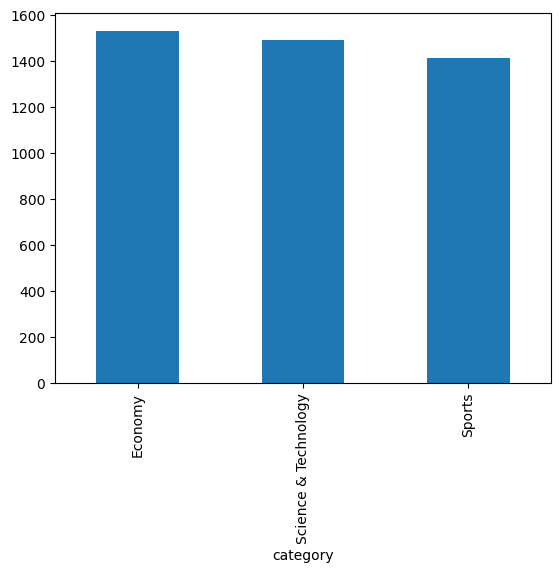

In [9]:
data_news['category'].value_counts().plot(kind='bar')


This dataset covers 3 categories : economy , science & tech and sports

In [10]:
category_counts = data_news['category'].value_counts()
print(category_counts)

category
Economy                 1532
Science & Technology    1493
Sports                  1413
Name: count, dtype: int64


In [11]:
data_news['article_length_words'] = data_news['article_content'].astype(str).apply(lambda x: len(x.split()))

# Check stats
print("\n--- article content stats ---")
print(data_news['article_length_words'].describe())



--- article content stats ---
count    4438.000000
mean      590.248085
std       385.625675
min        16.000000
25%       358.250000
50%       503.500000
75%       709.000000
max      4738.000000
Name: article_length_words, dtype: float64


The mean length of the article content is 503 words

In [12]:
data_news['title_length'] = data_news['title'].apply(len)
print("\n--- title stats ---")
print(data_news['title_length'].describe())


--- title stats ---
count    4438.00000
mean       58.21699
std         7.05243
min        13.00000
25%        55.00000
50%        60.00000
75%        63.00000
max        68.00000
Name: title_length, dtype: float64


The mean length of title is 60 words

# **Data preprocessing**

We will be using the spacy because it’s fast, accurate, all-in-one, and easy to use, making classic NLP tasks like tokenization,stemming, lemmatization, POS tagging, NER, and feature extraction much simpler

In [13]:
#first we'll load spacy and its language model which is the small english one (since it is fast)
nlp = spacy.load("en_core_web_sm")

In [14]:
def clean_text(text):
    """Clean text for news articles, keeping readability while removing noise like URLs, emails, emojis, etc."""
    if not text or not isinstance(text, str):
        return ""
    
    # Decode HTML entities
    text = html.unescape(text)
    
    # Remove HTML tags
    text = re.sub(r'<[^>]+>', ' ', text)
    
    # Remove URLs (improved pattern)
    text = re.sub(r'https?://[^\s]+|www\.[^\s]+|t\.co/\S+', ' ', text)
    
    # Remove social media artifacts
    text = re.sub(r'pic\.twitter\.com/\S+', ' ', text)
    text = re.sub(r'— .*?@\S+.*?(?:\s+\w+\s+\d{1,2},\s+\d{4})?', ' ', text)
    
    # Remove email addresses
    text = re.sub(r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b', ' ', text)
    
    # Remove hashtags and mentions
    text = re.sub(r'#\w+', ' ', text)
    text = re.sub(r'@\w+', ' ', text)
    
    # Remove arrows and special symbols
    text = re.sub(r'[→←↑↓➜]', ' ', text)
    
    # Remove promotional phrases and everything following until sentence boundary
    promo_phrases = [
        "ADVERTISEMENT","SPONSORED","SUBSCRIBE NOW","CLICK HERE",
        "READ MORE","LEARN MORE","SIGN UP","JOIN NOW","FOLLOW US",
        "WATCH NOW","SEE MORE","CONTINUE READING","NEXT ARTICLE",
        "SCROLL DOWN","BACK TO TOP","CONTACT US","PRIVACY POLICY",
        "TERMS OF SERVICE","ALL RIGHTS RESERVED"
    ]
    for phrase in promo_phrases:
        text = re.sub(r'\b' + re.escape(phrase) + r'\b[^.!?]*?(?:[.!?]|$)', ' ', text, flags=re.IGNORECASE)
    
    # Remove emojis (comprehensive pattern)
    emoji_pattern = re.compile("["
                               u"\U0001F600-\U0001F64F"  # emoticons
                               u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                               u"\U0001F680-\U0001F6FF"  # transport & map symbols
                               u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
                               u"\U00002700-\U000027BF"  # dingbats
                               u"\U0001F900-\U0001F9FF"  # Supplemental Symbols and Pictographs
                               u"\U00002600-\U000026FF"  # Miscellaneous Symbols
                               u"\U0001F170-\U0001F251"  # Enclosed characters
                               "]+", flags=re.UNICODE)
    text = emoji_pattern.sub(' ', text)
    
    # Handle dashes - keep word-internal hyphens, remove standalone dashes
    text = re.sub(r'\s+–\s+|\s+—\s+', ' ', text)  # remove spaced long dashes
    text = re.sub(r'^–\s*|^—\s*', '', text)       # remove leading dashes
    
    # Normalize quotes and apostrophes
    text = re.sub(r'["""«»]', '"', text)
    text = re.sub(r"['']", "'", text)
    
    # Fix spacing issues around punctuation
    text = re.sub(r'\s+([,.!?;:])', r'\1', text)
    text = re.sub(r'([.!?])\s*([A-Z])', r'\1 \2', text)
    
    # Remove extra whitespace and newlines
    text = re.sub(r'\s+', ' ', text)
    
    return text.strip()

# Example usage with before/after
sample_text = data_news['article_content'].iloc[0]

print("---- BEFORE ----")
print(sample_text)
print("\n---- AFTER ----")
print(clean_text(sample_text))


---- BEFORE ----
Telkes was an innovative scientist recognised for her contributions to the solar energy technologies.Hungarian-American scientist Maria Telkes is known for her contributions to solar energy technologies.Telkes, who died in 1995, invented the solar distiller as well as the first solar-powered heating system designed for residences.On Monday, Google changed its logo in 12 countries to a doodle, or illustration, in her honour.This is her story:Rays and shine! Today’s #GoogleDoodle celebrates the life of Dr. Mária Telkes, a pioneer in solar energy who's known as The Sun Queen 👑Learn more about her legacy here → https://t.co/pGuuVif9Ra pic.twitter.com/Ks0rgPXIcA— Google Doodles (@GoogleDoodles) December 12, 2022

---- AFTER ----
Telkes was an innovative scientist recognised for her contributions to the solar energy technologies. Hungarian-American scientist Maria Telkes is known for her contributions to solar energy technologies. Telkes, who died in 1995, invented the solar

We can say that overall this cleaning is robust , we can proceed with cleaning the article content 

In [15]:
data_news['article_content_cleaned'] = data_news['article_content'].apply(clean_text)
print(f"Cleaned {len(data_news)} articles successfully!")

Cleaned 4438 articles successfully!


# **CLASSIC NLP PIPELINE**

# **Tokenization using spacy**

In [16]:
tokenizer = nlp.tokenizer
docs = [nlp.tokenizer(text) for text in data_news['article_content_cleaned']]

Tokens display of the first 2 articles

In [17]:
# Extract tokens for each article
data_news['tokens'] = [[token.text for token in doc] for doc in docs]

for i, tokens in enumerate(data_news['tokens'].head(2)):
    print(f"Article {i} tokens: {tokens}\n")


Article 0 tokens: ['Telkes', 'was', 'an', 'innovative', 'scientist', 'recognised', 'for', 'her', 'contributions', 'to', 'the', 'solar', 'energy', 'technologies', '.', 'Hungarian', '-', 'American', 'scientist', 'Maria', 'Telkes', 'is', 'known', 'for', 'her', 'contributions', 'to', 'solar', 'energy', 'technologies', '.', 'Telkes', ',', 'who', 'died', 'in', '1995', ',', 'invented', 'the', 'solar', 'distiller', 'as', 'well', 'as', 'the', 'first', 'solar', '-', 'powered', 'heating', 'system', 'designed', 'for', 'residences', '.', 'On', 'Monday', ',', 'Google', 'changed', 'its', 'logo', 'in', '12', 'countries', 'to', 'a', 'doodle', ',', 'or', 'illustration', ',', 'in', 'her', 'honour', '.', 'This', 'is', 'her', 'story', ':', 'Rays', 'and', 'shine', '!', 'Today', '’s', 'celebrates', 'the', 'life', 'of', 'Dr.', 'Mária', 'Telkes', ',', 'a', 'pioneer', 'in', 'solar', 'energy', 'who', "'s", 'known', 'as', 'The', 'Sun', 'Queen']

Article 1 tokens: ['Firms', 'sent', 'technical', 'drawings', 'bluepr

Now we proceed with punctuation and stop word removal 

In [18]:
print(STOP_WORDS)

{'least', 'all', 'hereafter', 'whose', 'ca', 'thru', 'what', 'namely', 'nine', 'n‘t', 'everyone', 'even', 'none', 'such', "'d", 'on', 'at', 'hence', 'had', 'which', 'could', 'must', 'empty', 'yet', 'side', 'name', 'me', 'thereafter', 'alone', 'out', 'anyone', 'because', 'everywhere', 'itself', 'although', 'some', 'will', 'beforehand', 'done', 'we', 'very', 'someone', 'onto', 'did', 'along', 'against', 'whereby', 'toward', 'part', 'about', 'am', 'seeming', 'and', 'becoming', 'give', 'still', 'besides', 'less', 'that', 'not', 'one', 'nor', 'top', 'fifteen', '’ll', 'take', 'he', 'yourself', 'but', 'just', 'they', 'somewhere', 'there', 'amongst', 'for', 'within', 'ten', 'make', 'third', 'many', 'already', 'always', 'keep', 'does', 'ours', 'sometimes', 'himself', 'several', 'up', 'i', 'twenty', 'beyond', 'either', 'therein', 'more', 'since', 'almost', 'should', 'others', 'where', 'often', 'its', 'therefore', 'of', 'becomes', 'with', 'under', 'everything', 'may', 'used', 'my', 'back', 'aroun

In [19]:
# Remove stopwords
data_news['tokens_no_stop'] = data_news['tokens'].apply(lambda tokens: [token for token in tokens if token.lower() not in STOP_WORDS])

# Remove punctuation and lowercase (for Word2Vec preparation)
data_news['tokens_clean'] = data_news['tokens_no_stop'].apply(
    lambda tokens: [token.lower() for token in tokens if any(c.isalpha() for c in token)]
)

# Show first 5 articles with tokens after stop word removal and their counts
for i, row in data_news.head(5).iterrows():
    print(f"Article {i} tokens (no stop words): {row['tokens_no_stop']}")
    print(f"Number of tokens: {len(row['tokens_no_stop'])}")
    print(f"Article {i} tokens (cleaned): {row['tokens_clean']}")
    print(f"Number of clean tokens: {len(row['tokens_clean'])}\n")

# Count the number of tokens after stop word removal and cleaning
data_news['num_tokens_no_stop'] = data_news['tokens_no_stop'].apply(len)
data_news['num_tokens_clean'] = data_news['tokens_clean'].apply(len)

Article 0 tokens (no stop words): ['Telkes', 'innovative', 'scientist', 'recognised', 'contributions', 'solar', 'energy', 'technologies', '.', 'Hungarian', '-', 'American', 'scientist', 'Maria', 'Telkes', 'known', 'contributions', 'solar', 'energy', 'technologies', '.', 'Telkes', ',', 'died', '1995', ',', 'invented', 'solar', 'distiller', 'solar', '-', 'powered', 'heating', 'system', 'designed', 'residences', '.', 'Monday', ',', 'Google', 'changed', 'logo', '12', 'countries', 'doodle', ',', 'illustration', ',', 'honour', '.', 'story', ':', 'Rays', 'shine', '!', 'Today', 'celebrates', 'life', 'Dr.', 'Mária', 'Telkes', ',', 'pioneer', 'solar', 'energy', 'known', 'Sun', 'Queen']
Number of tokens: 68
Article 0 tokens (cleaned): ['telkes', 'innovative', 'scientist', 'recognised', 'contributions', 'solar', 'energy', 'technologies', 'hungarian', 'american', 'scientist', 'maria', 'telkes', 'known', 'contributions', 'solar', 'energy', 'technologies', 'telkes', 'died', 'invented', 'solar', 'dist

In [20]:
print(data_news['num_tokens_clean'].describe())

count    4438.000000
mean      328.032447
std       202.224695
min         7.000000
25%       205.000000
50%       285.000000
75%       393.750000
max      2567.000000
Name: num_tokens_clean, dtype: float64


On average , we have 285 tokens per article after the stop word & punctuation removal

In [21]:
#vocab size for cleaned tokens
all_clean_tokens = [token for tokens in data_news['tokens_clean'] for token in tokens]
clean_vocab_size = len(set(all_clean_tokens))
print(f"Vocabulary size after cleaning: {clean_vocab_size:,}")

Vocabulary size after cleaning: 59,542


# **Lemmatization**

In [22]:
# Apply lemmatization to clean tokens using spaCy
#context aware lemmatization
data_news['lemmas'] = data_news['tokens_clean'].apply(
    lambda tokens: [token.lemma_.lower() for token in nlp(" ".join(tokens))
                   if any(c.isalpha() for c in token.lemma_)]
)


In [23]:
# Display lemmatization results for first 2 articles
for i in range(2):
    print(f"=== ARTICLE {i} LEMMATIZATION COMPARISON ===")
    
    print(f"\nOriginal clean tokens (first 15):")
    print(data_news.iloc[i]['tokens_clean'][:15])
    
    print(f"\nAfter lemmatization (first 15):")
    print(data_news.iloc[i]['lemmas'][:15])
    
    print(f"\nSide-by-side comparison (first 10):")
    for orig, lemma in zip(data_news.iloc[i]['tokens_clean'][:10], data_news.iloc[i]['lemmas'][:10]):
        if orig != lemma:  # Only show words that changed
            print(f"  {orig} → {lemma}")
    
    print(f"\n" + "="*50 + "\n")

=== ARTICLE 0 LEMMATIZATION COMPARISON ===

Original clean tokens (first 15):
['telkes', 'innovative', 'scientist', 'recognised', 'contributions', 'solar', 'energy', 'technologies', 'hungarian', 'american', 'scientist', 'maria', 'telkes', 'known', 'contributions']

After lemmatization (first 15):
['telke', 'innovative', 'scientist', 'recognise', 'contribution', 'solar', 'energy', 'technology', 'hungarian', 'american', 'scientist', 'maria', 'telke', 'know', 'contribution']

Side-by-side comparison (first 10):
  telkes → telke
  recognised → recognise
  contributions → contribution
  technologies → technology


=== ARTICLE 1 LEMMATIZATION COMPARISON ===

Original clean tokens (first 15):
['firms', 'sent', 'technical', 'drawings', 'blueprints', 'customers', 'manufacturers', 'china', 'd', 'print', 'defence', 'prototypes', 'authorisation', 'department', 'commerce']

After lemmatization (first 15):
['firm', 'send', 'technical', 'drawing', 'blueprint', 'customer', 'manufacturer', 'china', 'd'

In [24]:
all_lemmas = [lemma for lemmas in data_news['lemmas'] for lemma in lemmas]
lemma_vocab_size = len(set(all_lemmas))
print(f"Vocabulary size after lemmatization: {lemma_vocab_size:,}")

Vocabulary size after lemmatization: 48,833


# **Stemming**

In [25]:
#since spacy doesnt have stemming built it we'll be using nltk's
stemmer = PorterStemmer()

data_news['stems'] = data_news['tokens_clean'].apply(
    lambda tokens: [stemmer.stem(token) for token in tokens]
)

In [26]:
# Display stemming results for first 2 articles
for i in range(2):
    print(f"=== ARTICLE {i} STEMMING COMPARISON ===")
    
    print(f"\nOriginal clean tokens (first 15):")
    print(data_news.iloc[i]['tokens_clean'][:15])
    
    print(f"\nAfter stemming (first 15):")
    print(data_news.iloc[i]['stems'][:15])
    
    print(f"\nSide-by-side comparison (first 10):")
    for orig, stem in zip(data_news.iloc[i]['tokens_clean'][:10], data_news.iloc[i]['stems'][:10]):
        if orig != stem:  # Only show words that changed
            print(f"  {orig} → {stem}")
    
    print(f"\n" + "="*50 + "\n")

# Check vocabulary size reduction from stemming
all_stems = [stem for stems in data_news['stems'] for stem in stems]
stem_vocab_size = len(set(all_stems))
print(f"Vocabulary size after stemming: {stem_vocab_size:,}")

=== ARTICLE 0 STEMMING COMPARISON ===

Original clean tokens (first 15):
['telkes', 'innovative', 'scientist', 'recognised', 'contributions', 'solar', 'energy', 'technologies', 'hungarian', 'american', 'scientist', 'maria', 'telkes', 'known', 'contributions']

After stemming (first 15):
['telk', 'innov', 'scientist', 'recognis', 'contribut', 'solar', 'energi', 'technolog', 'hungarian', 'american', 'scientist', 'maria', 'telk', 'known', 'contribut']

Side-by-side comparison (first 10):
  telkes → telk
  innovative → innov
  recognised → recognis
  contributions → contribut
  energy → energi
  technologies → technolog


=== ARTICLE 1 STEMMING COMPARISON ===

Original clean tokens (first 15):
['firms', 'sent', 'technical', 'drawings', 'blueprints', 'customers', 'manufacturers', 'china', 'd', 'print', 'defence', 'prototypes', 'authorisation', 'department', 'commerce']

After stemming (first 15):
['firm', 'sent', 'technic', 'draw', 'blueprint', 'custom', 'manufactur', 'china', 'd', 'print',

# **POS**

In [27]:
# POS tags for clean tokens
data_news['pos_tags'] = data_news['tokens_clean'].apply(
    lambda tokens: [(token.text, token.pos_) for token in nlp(" ".join(tokens))
                   if any(c.isalpha() for c in token.text)]
)

In [28]:
# Display POS results for first 2 articles
for i in range(2):
    print(f"=== ARTICLE {i} POS TAGGING ===")
    
    print(f"\nPOS Tags (first 15):")
    pos_sample = data_news.iloc[i]['pos_tags'][:15]
    for word, pos in pos_sample:
        print(f"  {word} → {pos}")
    
    print(f"\n" + "="*50 + "\n")

=== ARTICLE 0 POS TAGGING ===

POS Tags (first 15):
  telkes → NOUN
  innovative → ADJ
  scientist → NOUN
  recognised → VERB
  contributions → NOUN
  solar → ADJ
  energy → NOUN
  technologies → NOUN
  hungarian → ADJ
  american → PROPN
  scientist → PROPN
  maria → PROPN
  telkes → VERB
  known → VERB
  contributions → NOUN


=== ARTICLE 1 POS TAGGING ===

POS Tags (first 15):
  firms → NOUN
  sent → VERB
  technical → ADJ
  drawings → NOUN
  blueprints → VERB
  customers → NOUN
  manufacturers → NOUN
  china → PROPN
  d → PROPN
  print → NOUN
  defence → NOUN
  prototypes → NOUN
  authorisation → PROPN
  department → PROPN
  commerce → PROPN




# **NER**


In [29]:
# NER needs full text context, so reconstruct from clean tokens
data_news['entities'] = data_news['tokens_clean'].apply(
    lambda tokens: [(ent.text, ent.label_) for ent in nlp(" ".join(tokens)).ents]
)


In [30]:
# Display NER results for first 2 articles
for i in range(2):
    print(f"=== ARTICLE {i} NAMED ENTITIES ===")
    
    entities = data_news.iloc[i]['entities']
    if entities:
        for entity, label in entities:
            print(f"  '{entity}' → {label}")
    else:
        print("  No named entities found")
    
    print(f"\n" + "="*50 + "\n")


=== ARTICLE 0 NAMED ENTITIES ===
  'hungarian' → NORP
  'american' → NORP
  'monday' → DATE
  'today' → DATE
  'mária' → PERSON


=== ARTICLE 1 NAMED ENTITIES ===
  'china' → GPE
  'china' → GPE
  'manufacturing inc rapid' → ORG
  'llc prototype inc department commerce' → ORG
  'june' → DATE
  'china' → GPE
  'north carolina' → GPE
  'june' → DATE
  'china' → GPE
  'days' → DATE
  'june' → DATE
  'february' → DATE
  'july' → DATE
  'china' → GPE
  'december' → DATE
  'china' → GPE
  'june' → DATE
  'december' → DATE
  'thursday' → DATE
  'department commerce' → ORG
  'chinese' → NORP




# **EMBEDDING**

Now we will experiment with multiple word and sentence embedding techniques to represent our news articles and evaluate their impact on downstream tasks:

* CBOW
* Skip-gram
* BERT


In [31]:
# Prepare corpus: list of token lists 
corpus = data_news['tokens_clean'].tolist()

**CBOW**


In [32]:
model_cbow = Word2Vec(
    sentences=corpus,
    vector_size=100,   # embedding dimension
    window=5,          # context window
    min_count=2,       # ignore rare words
    sg=0,              # CBOW = 0, Skip-gram = 1
    workers=4,         # number of CPU threads
    epochs=15
)


In [33]:
word = 'science'
if word in model_cbow.wv:
    vector = model_cbow.wv[word]
    print(f"CBOW embedding for '{word}' (first 5 dims):", vector[:5])
else:
    print(f"'{word}' not in vocabulary")


CBOW embedding for 'science' (first 5 dims): [-0.791909    0.01137909 -1.147169    0.4754396  -0.50942713]


In [34]:
similar_words = model_cbow.wv.most_similar('economy', topn=4)
print("CBOW most similar to 'economy':", similar_words)


CBOW most similar to 'economy': [('recession', 0.5483693480491638), ('growth', 0.5387020707130432), ('economic', 0.5270970463752747), ('prospects', 0.5214621424674988)]


In [35]:
similarity = model_cbow.wv.similarity('economy', 'finance')
print("Similarity between 'economy' and 'finance':", similarity)


Similarity between 'economy' and 'finance': 0.44319546


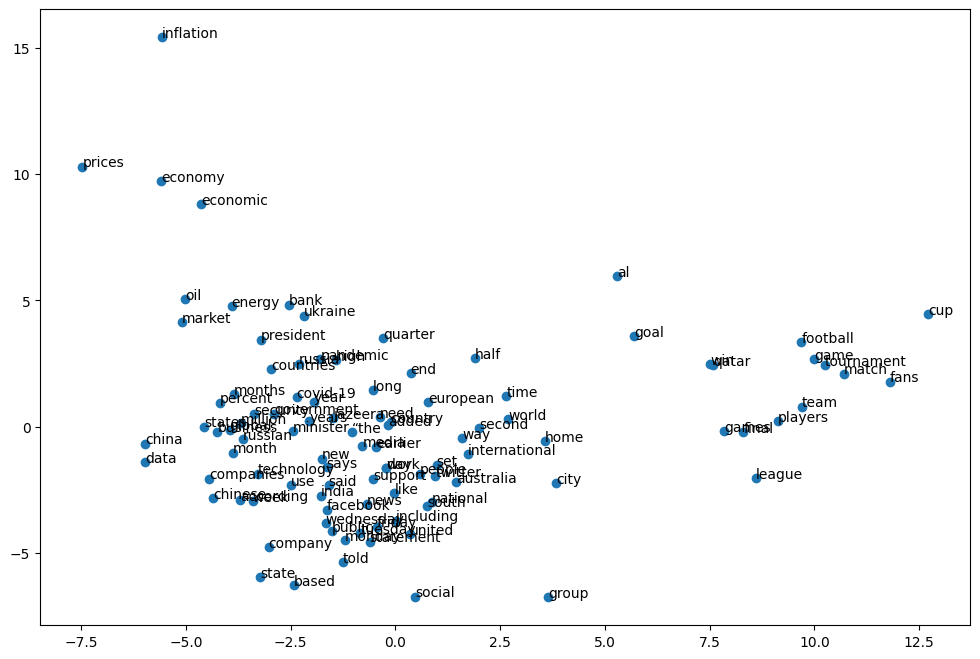

In [36]:
words = list(model_cbow.wv.index_to_key)[:100]  # first 100 words
vectors = [model_cbow.wv[w] for w in words]

pca = PCA(n_components=2)
vec_2d = pca.fit_transform(vectors)

plt.figure(figsize=(12,8))
plt.scatter(vec_2d[:,0], vec_2d[:,1])
for i, w in enumerate(words):
    plt.annotate(w, xy=(vec_2d[i,0], vec_2d[i,1]))
plt.show()


In [37]:
# ---- Skip-gram ----
model_skipgram = Word2Vec(
    sentences=corpus,
    vector_size=100,
    window=5,
    min_count=2,
    sg=1,              # Skip-gram
    workers=4,
    epochs=15
)

In [38]:
word = 'science'
if word in model_skipgram.wv:
    vector = model_skipgram.wv[word]
    print(f"Skip-gram embedding for '{word}' (first 5 dims):", vector[:5])
else:
    print(f"'{word}' not in vocabulary")


Skip-gram embedding for 'science' (first 5 dims): [-0.5881227   0.07680736  0.01827276  0.29549104 -0.06858955]


In [39]:
similar_words = model_skipgram.wv.most_similar('economy', topn=4)
print("Skip-gram most similar to 'science':", similar_words)


Skip-gram most similar to 'science': [('recession', 0.7185227870941162), ('moribund', 0.6427038908004761), ('economic', 0.6290591955184937), ('headwinds', 0.6179578304290771)]


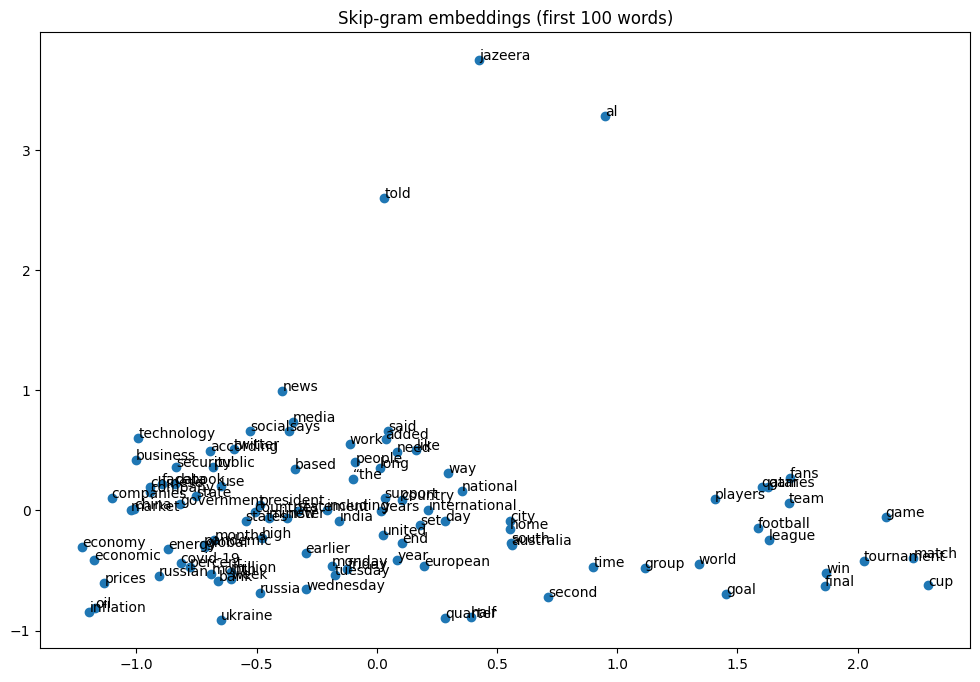

In [40]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

words = list(model_skipgram.wv.index_to_key)[:100]  # first 100 words
vectors = [model_skipgram.wv[w] for w in words]

pca = PCA(n_components=2)
vec_2d = pca.fit_transform(vectors)

plt.figure(figsize=(12,8))
plt.scatter(vec_2d[:,0], vec_2d[:,1])
for i, w in enumerate(words):
    plt.annotate(w, xy=(vec_2d[i,0], vec_2d[i,1]))
plt.title("Skip-gram embeddings (first 100 words)")
plt.show()


In [41]:
words = ['science','technology','research','economy','growth','finance','sports','football','olympics']
from itertools import combinations
for w1, w2 in combinations(words, 2):
    print(f"{w1} ~ {w2}: CBOW={model_cbow.wv.similarity(w1,w2):.2f}, Skip-gram={model_skipgram.wv.similarity(w1,w2):.2f}")


science ~ technology: CBOW=0.33, Skip-gram=0.50
science ~ research: CBOW=0.47, Skip-gram=0.43
science ~ economy: CBOW=0.01, Skip-gram=0.22
science ~ growth: CBOW=-0.07, Skip-gram=0.18
science ~ finance: CBOW=0.22, Skip-gram=0.30
science ~ sports: CBOW=0.35, Skip-gram=0.28
science ~ football: CBOW=-0.02, Skip-gram=0.14
science ~ olympics: CBOW=0.11, Skip-gram=0.13
technology ~ research: CBOW=0.33, Skip-gram=0.44
technology ~ economy: CBOW=0.17, Skip-gram=0.30
technology ~ growth: CBOW=0.21, Skip-gram=0.27
technology ~ finance: CBOW=0.08, Skip-gram=0.31
technology ~ sports: CBOW=0.04, Skip-gram=0.14
technology ~ football: CBOW=-0.12, Skip-gram=0.09
technology ~ olympics: CBOW=-0.04, Skip-gram=0.10
research ~ economy: CBOW=0.00, Skip-gram=0.17
research ~ growth: CBOW=0.14, Skip-gram=0.28
research ~ finance: CBOW=0.15, Skip-gram=0.26
research ~ sports: CBOW=0.06, Skip-gram=0.15
research ~ football: CBOW=-0.14, Skip-gram=0.06
research ~ olympics: CBOW=-0.04, Skip-gram=0.15
economy ~ growth:

In [44]:
from transformers import BertTokenizer, BertModel
import torch
from collections import defaultdict

# Load BERT
print("Loading BERT model...")
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = BertModel.from_pretrained('bert-base-uncased')
device = 'cuda' if torch.cuda.is_available() else 'cpu'
bert_model.to(device)
bert_model.eval()
print(f"BERT loaded on {device}")

# Get article texts
article_texts = data_news['article_content_cleaned'].tolist()

# Store embeddings per word per article: word -> article_id -> [embeddings]
word_article_embeddings = defaultdict(lambda: defaultdict(list))
batch_size = 8
processed_articles = 0

print("Extracting contextual embeddings for ALL words...")
for i in range(0, len(article_texts), batch_size):
    batch_texts = article_texts[i:i+batch_size]
    
    # Tokenize
    encoded = tokenizer(
        batch_texts,
        padding=True,
        truncation=True,
        max_length=512,
        return_tensors='pt'
    )
    encoded = {k: v.to(device) for k, v in encoded.items()}
    
    # Get embeddings
    with torch.no_grad():
        outputs = bert_model(**encoded)
        hidden_states = outputs.last_hidden_state  # (batch_size, seq_len, 768)
        
        # Process each article
        for batch_idx, text in enumerate(batch_texts):
            article_id = i + batch_idx  # Global article index
            tokens = tokenizer.convert_ids_to_tokens(encoded['input_ids'][batch_idx])
            
            for pos, token in enumerate(tokens):
                if token not in ['[CLS]', '[SEP]', '[PAD]', '[UNK]']:
                    embedding = hidden_states[batch_idx, pos, :].cpu()
                    word_article_embeddings[token][article_id].append(embedding)
    
    processed_articles += len(batch_texts)
    if processed_articles % 100 == 0:
        print(f"Processed {processed_articles}/{len(article_texts)} articles")

print(f"\nProcessed {len(article_texts)} articles")
print("Averaging embeddings per word per article...")

# Average embeddings within each article for each word
word_contexts = defaultdict(list)  # word -> list of averaged embeddings per article

for word, articles in word_article_embeddings.items():
    for article_id, embeddings in articles.items():
        if embeddings:  # Check if list is not empty
            # Average all occurrences of this word in this article
            avg_embedding = torch.stack(embeddings).mean(dim=0)
            word_contexts[word].append(avg_embedding)

print(f"Final result: {len(word_contexts)} unique tokens")
print(f"Sample counts per word:")
for word in list(word_contexts.keys())[:5]:  # Show first 5 words
    print(f"  '{word}': {len(word_contexts[word])} article contexts")

# Clean up memory
del word_article_embeddings

Loading BERT model...
BERT loaded on cuda
Extracting contextual embeddings for ALL words...
Processed 200/4438 articles
Processed 400/4438 articles
Processed 600/4438 articles
Processed 800/4438 articles
Processed 1000/4438 articles
Processed 1200/4438 articles
Processed 1400/4438 articles
Processed 1600/4438 articles
Processed 1800/4438 articles
Processed 2000/4438 articles
Processed 2200/4438 articles
Processed 2400/4438 articles
Processed 2600/4438 articles
Processed 2800/4438 articles
Processed 3000/4438 articles
Processed 3200/4438 articles
Processed 3400/4438 articles
Processed 3600/4438 articles
Processed 3800/4438 articles
Processed 4000/4438 articles
Processed 4200/4438 articles
Processed 4400/4438 articles

Processed 4438 articles
Averaging embeddings per word per article...
Final result: 22547 unique tokens
Sample counts per word:
  'tel': 47 article contexts
  '##kes': 31 article contexts
  'was': 3142 article contexts
  'an': 3046 article contexts
  'innovative': 20 articl

In [45]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns

# Target words
words = ['algorithm', 'software', 'computer', 'data',
         'goal', 'match', 'team', 'championship', 
         'profit', 'market', 'bank', 'currency']

# Word2Vec similarity helper
def get_w2v_vector(model, word):
    return model.wv[word] if word in model.wv else None

def compute_w2v_similarity(model):
    size = len(words)
    sim_matrix = np.zeros((size, size))
    for i, w1 in enumerate(words):
        v1 = get_w2v_vector(model, w1)
        for j, w2 in enumerate(words):
            v2 = get_w2v_vector(model, w2)
            if v1 is not None and v2 is not None:
                sim_matrix[i, j] = cosine_similarity([v1], [v2])[0][0]
            else:
                sim_matrix[i, j] = np.nan
    return pd.DataFrame(sim_matrix, index=words, columns=words)

# BERT contextual similarity using existing embeddings (word_contexts)
def compute_bert_contextual_similarity(word_contexts):
    size = len(words)
    sim_matrix = np.zeros((size, size))
    
    for i, w1 in enumerate(words):
        for j, w2 in enumerate(words):
            if w1 in word_contexts and w2 in word_contexts:
                contexts1 = word_contexts[w1]
                contexts2 = word_contexts[w2]
                
                if contexts1 and contexts2:
                    # Max similarity among all contextual embeddings
                    sims = [cosine_similarity([e1.numpy()], [e2.numpy()])[0][0] 
                            for e1 in contexts1 for e2 in contexts2]
                    sim_matrix[i, j] = max(sims)
                else:
                    sim_matrix[i, j] = np.nan
            else:
                sim_matrix[i, j] = np.nan
    return pd.DataFrame(sim_matrix, index=words, columns=words)

# Compute similarity matrices
cbow_sim = compute_w2v_similarity(model_cbow)
skip_sim = compute_w2v_similarity(model_skipgram)
bert_sim = compute_bert_contextual_similarity(word_contexts)  # use embeddings you already computed

# Plot 3 heatmaps
fig, axes = plt.subplots(1, 3, figsize=(24, 6))
sns.heatmap(cbow_sim, annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=axes[0], fmt='.2f')
axes[0].set_title("CBOW Similarity")
sns.heatmap(skip_sim, annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=axes[1], fmt='.2f')
axes[1].set_title("Skip-gram Similarity")
sns.heatmap(bert_sim, annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=axes[2], fmt='.2f')
axes[2].set_title("BERT Contextual (Max)")
plt.tight_layout()
plt.show()


KeyboardInterrupt: 

this method will be faster since the cosine similarity wont be between a lot of embeddings so we had the idea to average all context per word , but as we know bert's strength is capturing the context of the same token when its used in different contexts

Checking word coverage in embeddings:
'algorithm': 31 contexts
'software': 136 contexts
'computer': 82 contexts
'data': 707 contexts
'goal': 496 contexts
'match': 655 contexts
'team': 1015 contexts
'championship': 97 contexts
'profit': 189 contexts
'market': 745 contexts
'bank': 468 contexts
'currency': 154 contexts

Computing similarity matrices...
Creating comparison plots...


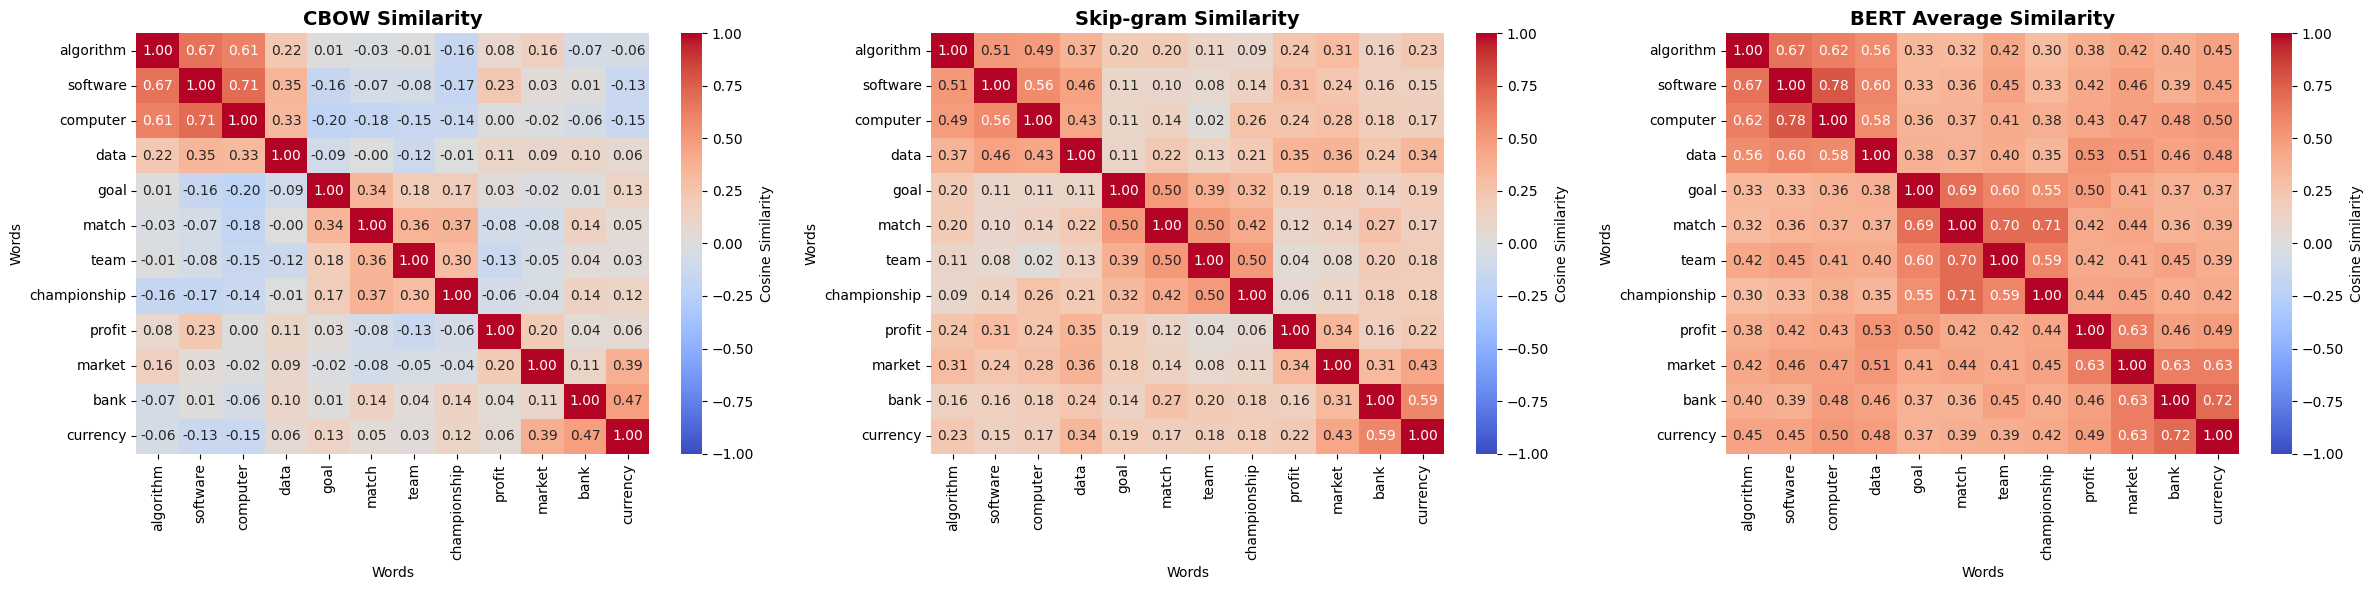

In [47]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns
import torch

# Target words
words = ['algorithm', 'software', 'computer', 'data',
         'goal', 'match', 'team', 'championship', 
         'profit', 'market', 'bank', 'currency']

# Word2Vec similarity helper
def get_w2v_vector(model, word):
    return model.wv[word] if word in model.wv else None

def compute_w2v_similarity(model):
    size = len(words)
    sim_matrix = np.zeros((size, size))
    for i, w1 in enumerate(words):
        v1 = get_w2v_vector(model, w1)
        for j, w2 in enumerate(words):
            v2 = get_w2v_vector(model, w2)
            if v1 is not None and v2 is not None:
                sim_matrix[i, j] = cosine_similarity([v1], [v2])[0][0]
            else:
                sim_matrix[i, j] = np.nan
    return pd.DataFrame(sim_matrix, index=words, columns=words)

# BERT average similarity (fastest approach)
def compute_bert_average_similarity(word_contexts):
    """
    Average all contexts per word first, then compute similarities
    """
    size = len(words)
    sim_matrix = np.zeros((size, size))
    
    # Pre-compute average embedding per word
    avg_embeddings = {}
    for word in words:
        if word in word_contexts and word_contexts[word]:
            # Average all contexts for this word
            avg_embeddings[word] = torch.stack(word_contexts[word]).mean(dim=0).numpy()
        else:
            avg_embeddings[word] = None
    
    # Compute pairwise similarities
    for i, w1 in enumerate(words):
        for j, w2 in enumerate(words):
            if avg_embeddings[w1] is not None and avg_embeddings[w2] is not None:
                sim_matrix[i, j] = cosine_similarity([avg_embeddings[w1]], [avg_embeddings[w2]])[0][0]
            else:
                sim_matrix[i, j] = np.nan
    
    return pd.DataFrame(sim_matrix, index=words, columns=words)

# Check word coverage first
print("Checking word coverage in embeddings:")
for word in words:
    if word in word_contexts:
        print(f"'{word}': {len(word_contexts[word])} contexts")
    else:
        print(f"'{word}': NOT FOUND")

print("\nComputing similarity matrices...")

# Compute similarity matrices
cbow_sim = compute_w2v_similarity(model_cbow)
skip_sim = compute_w2v_similarity(model_skipgram)
bert_sim = compute_bert_average_similarity(word_contexts)

print("Creating comparison plots...")

# Plot 3 heatmaps
fig, axes = plt.subplots(1, 3, figsize=(24, 6))

# CBOW heatmap
sns.heatmap(cbow_sim, annot=True, cmap='coolwarm', vmin=-1, vmax=1, 
            ax=axes[0], fmt='.2f', cbar_kws={'label': 'Cosine Similarity'})
axes[0].set_title("CBOW Similarity", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Words")
axes[0].set_ylabel("Words")

# Skip-gram heatmap  
sns.heatmap(skip_sim, annot=True, cmap='coolwarm', vmin=-1, vmax=1, 
            ax=axes[1], fmt='.2f', cbar_kws={'label': 'Cosine Similarity'})
axes[1].set_title("Skip-gram Similarity", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Words")
axes[1].set_ylabel("Words")

# BERT heatmap
sns.heatmap(bert_sim, annot=True, cmap='coolwarm', vmin=-1, vmax=1, 
            ax=axes[2], fmt='.2f', cbar_kws={'label': 'Cosine Similarity'})
axes[2].set_title("BERT Average Similarity", fontsize=14, fontweight='bold')
axes[2].set_xlabel("Words")
axes[2].set_ylabel("Words")

plt.tight_layout()
plt.show()

## Conclusion

**Comparison of Embedding Models: CBOW vs Skip-gram vs BERT**

- **CBOW**: Efficient for frequent words; captures general context but may miss subtle relationships in rare words.  
- **Skip-gram**: Better for rare words and capturing nuanced semantic relationships; slightly higher similarity scores for domain-specific terms.  
- **BERT**: Context-aware embeddings; captures nuanced meanings by considering surrounding text; better for sentence-level and context-sensitive tasks.  

**Insights:**

- CBOW and Skip-gram are lightweight and fast for word-level embeddings.  
- BERT is more computationally intensive but provides richer, context-sensitive representations.  

**Recommendation:**

- Use **Word2Vec** (CBOW/Skip-gram) for quick similarity and classical NLP tasks.  
- Use **BERT** when understanding context or sentence semantics is critical.
